# Etapa 4: Modelagem com Regressão Linear

Entrada: `imoveis_limpos.csv`. Modelos, do mais simples ao mais completo:

| # | Modelo | Variáveis |
|---|---|---|
| a | **RLS** | só `area_m2` |
| b | **RLM** | `area_m2, quartos, banheiros, vagas` |
| c | RLM + **One-Hot** | (b) + `bairro` + `tipo` |
| d | **Ridge** e **Lasso** | (c), padronizado, α por validação cruzada |
| e | RLM com **log(preco)** | (c) |
| f | RLM **log-log** | (c), com `log(preco)` e `log(area_m2)` |

Depois vêm o **VIF**, os **resíduos**, a **interpretação dos coeficientes** e uma previsão de exemplo.

## Imports e dados

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_theme(style="whitegrid")
Path("figs").mkdir(exist_ok=True)

df = pd.read_csv("imoveis_limpos.csv", dtype={"id": str})
print(df.shape)
df.head()

(642, 14)


,id,preco,area_m2,quartos,banheiros,vagas,bairro,tipo,preco_m2,condominio,iptu,bairro_anuncio,url,data_coleta
0,2821599338,1959000.0,125.0,2.0,2.0,1.0,Asa Sul,cobertura,15672.000000,0.0,0.0,Asa Sul,https://www.vivareal.com.br/imovel/cobertura-2...,2026-09-27
1,2893493673,360000.0,27.0,1.0,1.0,2.0,Asa Sul,kitnet,13333.333333,390.0,819.0,Asa Sul,https://www.vivareal.com.br/imovel/kitnet-1-qu...,2026-09-27
2,2863998901,345000.0,25.0,1.0,1.0,1.0,Asa Sul,kitnet,13800.000000,0.0,0.0,Asa Sul,https://www.vivareal.com.br/imovel/kitnet-1-qu...,2026-09-27
3,2899174503,410000.0,27.0,1.0,1.0,0.0,Asa Sul,kitnet,15185.185185,0.0,0.0,Asa Sul,https://www.vivareal.com.br/imovel/kitnet-1-qu...,2026-09-27
4,2735690215,390000.0,26.0,1.0,1.0,2.0,Asa Sul,kitnet,15000.000000,431.0,2250.0,Asa Sul,https://www.vivareal.com.br/imovel/kitnet-1-qu...,2026-09-27


## Melhorando o Output

In [2]:
def formatar_numero_br(valor, casas=2):
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def formatar_moeda_br(valor, casas=0):
    return f"R$ {formatar_numero_br(valor, casas)}"


def exibir_caixa(titulo, linhas):
    conteudos = [f" {chave}: {valor}" for chave, valor in linhas]
    largura = max(len(titulo) + 2, *(len(c) + 1 for c in conteudos))
    print("╭" + "─" * largura + "╮")
    print("│" + titulo.center(largura) + "│")
    print("├" + "─" * largura + "┤")
    for conteudo in conteudos:
        print("│" + conteudo.ljust(largura) + "│")
    print("╰" + "─" * largura + "╯")


reais_mi = FuncFormatter(lambda v, _: f"R$ {formatar_numero_br(v / 1e6, 1)} mi")
milhoes = FuncFormatter(lambda v, _: formatar_numero_br(v / 1e6, 1))    # versão curta, para eixos apertados

## Treino e teste

Sorteamos **uma única vez** quais imóveis ficam no teste (20%) e reaproveitamos esses índices em **todos** os modelos. Assim a comparação é justa: todo mundo faz a mesma prova.

In [3]:
FEATURES = ["area_m2", "quartos", "banheiros", "vagas"]
y = df["preco"]

idx_treino, idx_teste = train_test_split(df.index, test_size=0.2, random_state=42)
y_train, y_test = y.loc[idx_treino], y.loc[idx_teste]
print(f"Treino: {len(idx_treino)} imóveis | Teste: {len(idx_teste)} imóveis")

resultados = []


def avaliar(nome, y_real, y_previsto):
    r2 = r2_score(y_real, y_previsto)
    rmse = np.sqrt(mean_squared_error(y_real, y_previsto))
    mae = mean_absolute_error(y_real, y_previsto)
    print(f"{nome:<26} R²={r2:6.3f}   RMSE={formatar_moeda_br(rmse):>14}   MAE={formatar_moeda_br(mae):>14}")
    resultados.append({"modelo": nome, "R2": r2, "RMSE": rmse, "MAE": mae})

Treino: 513 imóveis | Teste: 129 imóveis


## (a) Regressão Linear Simples: preço ~ área

$$\widehat{\text{preço}} = \beta_0 + \beta_1 \cdot \text{área}$$

In [4]:
X_rls = df[["area_m2"]]
rls = LinearRegression().fit(X_rls.loc[idx_treino], y_train)
avaliar("(a) RLS área", y_test, rls.predict(X_rls.loc[idx_teste]))
print(f"\npreço = {formatar_moeda_br(rls.intercept_)} + {formatar_moeda_br(rls.coef_[0])} × área")

(a) RLS área               R²= 0.580   RMSE=    R$ 850.648   MAE=    R$ 577.572

preço = R$ 661.370 + R$ 6.891 × área


## (b) RLM com as variáveis numéricas

$$\widehat{\text{preço}} = \beta_0 + \beta_1\,\text{área} + \beta_2\,\text{quartos} + \beta_3\,\text{banheiros} + \beta_4\,\text{vagas}$$

In [5]:
X_num = df[FEATURES]
rlm = LinearRegression().fit(X_num.loc[idx_treino], y_train)
avaliar("(b) RLM numéricas", y_test, rlm.predict(X_num.loc[idx_teste]))
print("\nCoeficientes (R$ por +1 unidade):")
print(pd.Series(rlm.coef_, index=FEATURES).round(0))
print("Intercepto:", round(rlm.intercept_))

(b) RLM numéricas          R²= 0.713   RMSE=    R$ 703.484   MAE=    R$ 443.820

Coeficientes (R$ por +1 unidade):
area_m2        1432.0
quartos      135539.0
banheiros    369813.0
vagas         84457.0
dtype: float64
Intercepto: -34954


## (c) + bairro e tipo (One-Hot Encoding)

Bairros com menos de 5 anúncios viram **"Outros"** (poucos pontos não ensinam nada ao modelo). `drop_first=True` remove uma categoria de cada variável, que vira a **referência** (evita a armadilha das dummies). Aqui as referências são **Asa Norte** e **apartamento** (primeiras em ordem alfabética).

In [6]:
MIN_ANUNCIOS_BAIRRO = 5
contagem = df["bairro"].value_counts()
df["bairro_grp"] = df["bairro"].where(df["bairro"].map(contagem) >= MIN_ANUNCIOS_BAIRRO, "Outros")

X2 = pd.get_dummies(df[FEATURES + ["bairro_grp", "tipo"]], columns=["bairro_grp", "tipo"],
                    drop_first=True, dtype=int)
X2_train, X2_test = X2.loc[idx_treino], X2.loc[idx_teste]
print("Colunas:", list(X2.columns))

rlm2 = LinearRegression().fit(X2_train, y_train)
avaliar("(c) RLM + bairro + tipo", y_test, rlm2.predict(X2_test))

Colunas: ['area_m2', 'quartos', 'banheiros', 'vagas', 'bairro_grp_Asa Sul', 'bairro_grp_Cruzeiro Novo', 'bairro_grp_Lago Norte', 'bairro_grp_Lago Sul', 'bairro_grp_Noroeste', 'bairro_grp_Outros', 'bairro_grp_Sudoeste', 'tipo_casa', 'tipo_cobertura', 'tipo_kitnet']
(c) RLM + bairro + tipo    R²= 0.832   RMSE=    R$ 538.361   MAE=    R$ 348.723


## (d) Ridge e Lasso

Com várias dummies, a RLM comum pode "decorar" o treino. Ridge (L2) e Lasso (L1) adicionam um "freio" nos coeficientes. **Padronizar** (`StandardScaler`) é obrigatório para a penalidade ser justa entre variáveis de escalas diferentes. O `Pipeline` garante que o scaler aprende média e desvio **só no treino**.

In [7]:
alphas = np.logspace(-2, 4, 50)

ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas)).fit(X2_train, y_train)
avaliar("(d) Ridge", y_test, ridge.predict(X2_test))

lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=50_000, random_state=42)).fit(X2_train, y_train)
avaliar("(d) Lasso", y_test, lasso.predict(X2_test))

print(f"\nα Ridge: {ridge[-1].alpha_:.2f} | α Lasso: {formatar_numero_br(lasso[-1].alpha_, 0)}")
zerados = X2.columns[lasso[-1].coef_ == 0]
print(f"Lasso zerou {len(zerados)} de {X2.shape[1]} coeficientes: {list(zerados)}")

(d) Ridge                  R²= 0.831   RMSE=    R$ 540.468   MAE=    R$ 349.675
(d) Lasso                  R²= 0.830   RMSE=    R$ 541.100   MAE=    R$ 346.511

α Ridge: 4.94 | α Lasso: 6.596
Lasso zerou 1 de 14 coeficientes: ['bairro_grp_Outros']


## (e) Transformação logarítmica

Treinamos em $\ln(\text{preço})$ e voltamos para reais com `np.exp` **antes** de medir o erro (senão compararíamos reais com logaritmos).

In [8]:
rlm_log = LinearRegression().fit(X2_train, np.log(y_train))
previsto_log = np.exp(rlm_log.predict(X2_test))
avaliar("(e) RLM + log(preco)", y_test, previsto_log)

(e) RLM + log(preco)       R²= 0.780   RMSE=    R$ 615.850   MAE=    R$ 375.845


## (f) Modelo log-log: log também na área

O (e) quase não melhora em relação ao (c). Motivo: com $\ln(\text{preço})$ e área linear, o modelo supõe que **cada m²** multiplica o preço pelo mesmo fator. Assim, um imóvel com 300 m² a mais que outro custaria $e^{300\beta}$ vezes mais, e o preço "explode" nos imóveis grandes. Na prática, o preço cresce **proporcionalmente** à área:

$$\ln(\widehat{\text{preço}}) = \beta_0 + \beta_1 \ln(\text{área}) + \beta_2\,\text{quartos} + \dots$$

Aqui $\beta_1$ é uma **elasticidade**: +1% de área está associado a +$\beta_1$% no preço.

In [9]:
X3 = X2.assign(area_m2=np.log(X2["area_m2"])).rename(columns={"area_m2": "log_area_m2"})
X3_train, X3_test = X3.loc[idx_treino], X3.loc[idx_teste]

rlm_loglog = LinearRegression().fit(X3_train, np.log(y_train))
previsto_loglog = np.exp(rlm_loglog.predict(X3_test))
avaliar("(f) RLM log-log", y_test, previsto_loglog)
print(f"\nElasticidade preço-área: {rlm_loglog.coef_[0]:.3f} (+10% de área → {100 * (1.1 ** rlm_loglog.coef_[0] - 1):+.1f}% no preço)")

(f) RLM log-log            R²= 0.858   RMSE=    R$ 494.367   MAE=    R$ 286.678

Elasticidade preço-área: 0.752 (+10% de área → +7.4% no preço)


## Comparação dos modelos

In [10]:
tabela = pd.DataFrame(resultados).set_index("modelo")
display(tabela.style.format({"R2": "{:.3f}", "RMSE": formatar_moeda_br, "MAE": formatar_moeda_br})
        .highlight_max(subset="R2", color="#c6efce")
        .highlight_min(subset=["RMSE", "MAE"], color="#c6efce"))

,R2,RMSE,MAE
modelo,,,
(a) RLS área,0.580,R$ 850.648,R$ 577.572
(b) RLM numéricas,0.713,R$ 703.484,R$ 443.820
(c) RLM + bairro + tipo,0.832,R$ 538.361,R$ 348.723
(d) Ridge,0.831,R$ 540.468,R$ 349.675
(d) Lasso,0.830,R$ 541.100,R$ 346.511
(e) RLM + log(preco),0.780,R$ 615.850,R$ 375.845
(f) RLM log-log,0.858,R$ 494.367,R$ 286.678


## Multicolinearidade (VIF)

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

onde $R_j^2$ vem da regressão da variável $j$ contra as outras. Leitura: 1 a 5 é aceitável, 5 a 10 é preocupante e acima de 10 é grave.

In [11]:
Xv = add_constant(df[FEATURES])
vif = pd.DataFrame({
    "variavel": Xv.columns,
    "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
})
vif[vif["variavel"] != "const"].round(2)

,variavel,VIF
1,area_m2,4.11
2,quartos,3.33
3,banheiros,4.04
4,vagas,2.18


## Resíduos

Se os resíduos formam um **funil** (espalham mais conforme o preço previsto cresce), o erro não é constante (*heterocedasticidade*). Esse é o sintoma que a escala log corrige.

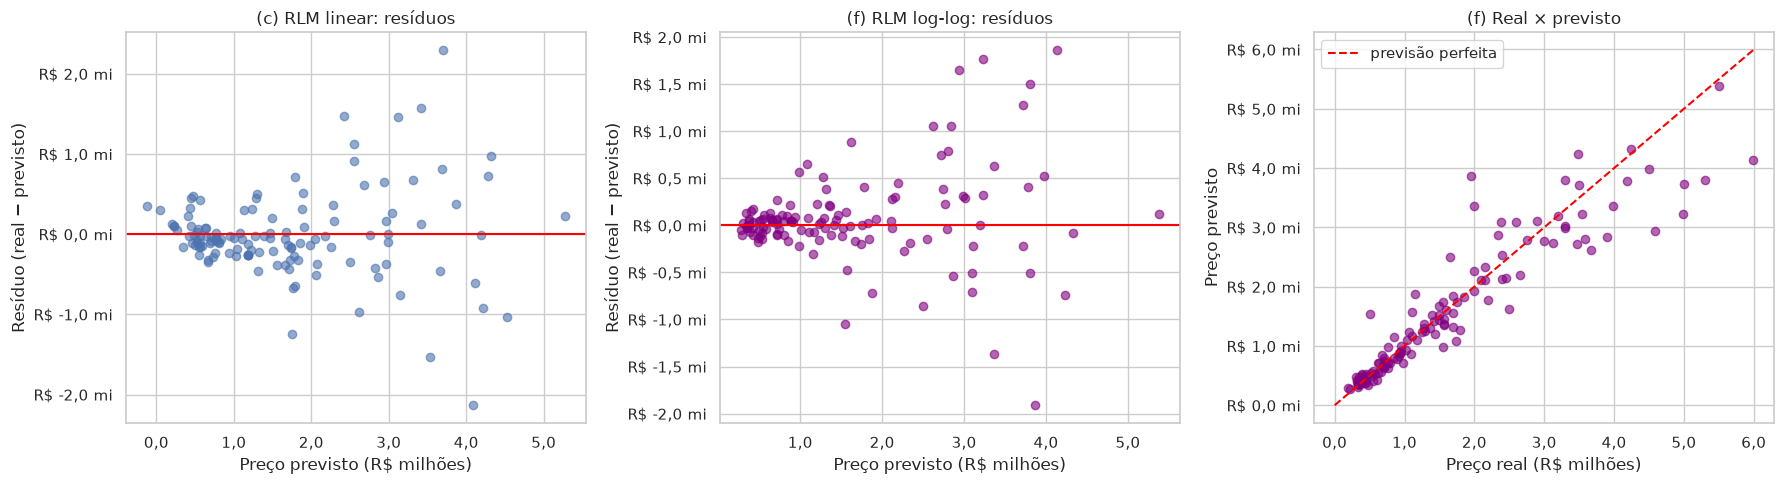

In [12]:
previsto_lin = rlm2.predict(X2_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(previsto_lin, y_test - previsto_lin, alpha=0.6)
axes[0].axhline(0, color="red")
axes[0].set_title("(c) RLM linear: resíduos")
axes[1].scatter(previsto_loglog, y_test - previsto_loglog, alpha=0.6, color="purple")
axes[1].axhline(0, color="red")
axes[1].set_title("(f) RLM log-log: resíduos")
for ax in axes[:2]:
    ax.set_xlabel("Preço previsto (R$ milhões)"); ax.set_ylabel("Resíduo (real − previsto)")
    ax.xaxis.set_major_formatter(milhoes); ax.yaxis.set_major_formatter(reais_mi)

limite = [0, max(y_test.max(), previsto_loglog.max())]
axes[2].scatter(y_test, previsto_loglog, alpha=0.6, color="purple")
axes[2].plot(limite, limite, color="red", ls="--", label="previsão perfeita")
axes[2].set_xlabel("Preço real (R$ milhões)"); axes[2].set_ylabel("Preço previsto")
axes[2].set_title("(f) Real × previsto"); axes[2].legend()
axes[2].xaxis.set_major_formatter(milhoes); axes[2].yaxis.set_major_formatter(reais_mi)
plt.tight_layout()
plt.savefig("figs/residuos.png", dpi=150)
plt.show()

## Interpretação dos coeficientes

**Modelo linear (c), em R\$:** "mantidas as demais variáveis constantes, cada unidade a mais está associada a +β reais no preço".

**Modelo log-log (f), em %:** efeito de +1 unidade $= (e^{\beta} - 1) \times 100\%$. A área é exceção: seu β é a elasticidade (+1% de área → +β% no preço).

> ⚠️ **Associação não é causa.** "Imóveis com mais banheiros custam X% a mais" ≠ "construir um banheiro aumenta o preço em X%".

In [13]:
efeito_pct = 100 * (np.exp(rlm_loglog.coef_) - 1)
efeito_pct[0] = rlm_loglog.coef_[0]                      # área: elasticidade, não (e^β − 1)
coefs = pd.DataFrame({"R$ (modelo c)": rlm2.coef_, "% (modelo f, log-log)": efeito_pct}, index=X2.columns)
display(coefs.style.format({"R$ (modelo c)": formatar_moeda_br, "% (modelo f, log-log)": "{:+.2f}%"}))

c, p = coefs["R$ (modelo c)"], coefs["% (modelo f, log-log)"]
print(f"• Cada m² adicional está associado a {formatar_moeda_br(c['area_m2'])} a mais no preço (modelo c);"
      f" no log-log, +10% de área → {100 * (1.1 ** rlm_loglog.coef_[0] - 1):+.1f}% no preço.")
print(f"• Cada vaga de garagem adicional: {formatar_moeda_br(c['vagas'])} ({p['vagas']:+.1f}%).")
print(f"• Cada banheiro adicional: {formatar_moeda_br(c['banheiros'])} ({p['banheiros']:+.1f}%).")
print(f"• Cada quarto adicional, mantida a área: {formatar_moeda_br(c['quartos'])} ({p['quartos']:+.1f}%).")
for coluna in [col for col in X2.columns if col.startswith(("bairro_grp_", "tipo_"))]:
    nome = coluna.removeprefix("bairro_grp_").removeprefix("tipo_")
    referencia = "Asa Norte" if coluna.startswith("bairro_grp_") else "apartamento"
    print(f"• {nome} vs. {referencia} (imóvel igual): {p[coluna]:+.1f}%")

,R$ (modelo c),"% (modelo f, log-log)"
area_m2,R$ 5.614,+0.75%
quartos,R$ 87.790,+0.25%
banheiros,R$ 274.345,+7.87%
vagas,R$ 131.264,+5.82%
bairro_grp_Asa Sul,R$ 113.704,+3.03%
bairro_grp_Cruzeiro Novo,R$ -357.185,-31.20%
bairro_grp_Lago Norte,R$ -340.376,-16.08%
bairro_grp_Lago Sul,R$ 147.113,-1.38%
bairro_grp_Noroeste,R$ 198.726,+9.99%
bairro_grp_Outros,R$ -35.029,-2.24%


• Cada m² adicional está associado a R$ 5.614 a mais no preço (modelo c); no log-log, +10% de área → +7.4% no preço.
• Cada vaga de garagem adicional: R$ 131.264 (+5.8%).
• Cada banheiro adicional: R$ 274.345 (+7.9%).
• Cada quarto adicional, mantida a área: R$ 87.790 (+0.2%).
• Asa Sul vs. Asa Norte (imóvel igual): +3.0%
• Cruzeiro Novo vs. Asa Norte (imóvel igual): -31.2%
• Lago Norte vs. Asa Norte (imóvel igual): -16.1%
• Lago Sul vs. Asa Norte (imóvel igual): -1.4%
• Noroeste vs. Asa Norte (imóvel igual): +10.0%
• Outros vs. Asa Norte (imóvel igual): -2.2%
• Sudoeste vs. Asa Norte (imóvel igual): +7.3%
• casa vs. apartamento (imóvel igual): -48.6%
• cobertura vs. apartamento (imóvel igual): -8.1%
• kitnet vs. apartamento (imóvel igual): -19.6%


## Usando o modelo: quanto "deveria" custar aquele imóvel do começo?

No primeiro rascunho do `01_coleta` havia um imóvel de exemplo: **Asa Sul, 75 m², 1 quarto, com vaga, anunciado por R$ 1.500.000**. Vamos perguntar aos modelos (c) e (f), completando com 1 banheiro.

In [14]:
exemplo = {"area_m2": 75.0, "quartos": 1, "banheiros": 1, "vagas": 1, "bairro_grp": "Asa Sul", "tipo": "apartamento"}
preco_anunciado = 1_500_000.0

linha = pd.get_dummies(pd.DataFrame([exemplo]), columns=["bairro_grp", "tipo"], dtype=int)
linha = linha.reindex(columns=X2.columns, fill_value=0)       # mesmas colunas, na mesma ordem do treino
linha_log = linha.assign(area_m2=np.log(linha["area_m2"])).rename(columns={"area_m2": "log_area_m2"})

estimado_lin = float(rlm2.predict(linha)[0])
estimado_loglog = float(np.exp(rlm_loglog.predict(linha_log))[0])

exibir_caixa("PREVISÃO PARA O IMÓVEL DE EXEMPLO", [
    ("Imóvel", "Apto Asa Sul, 75 m², 1 qto, 1 banh, 1 vaga"),
    ("Preço anunciado", formatar_moeda_br(preco_anunciado)),
    ("Estimado (c) linear", formatar_moeda_br(estimado_lin)),
    ("Estimado (f) log-log", formatar_moeda_br(estimado_loglog)),
    ("Anunciado vs. (f)", f"{100 * (preco_anunciado / estimado_loglog - 1):+.1f}%"),
    ("Erro típico (f), MAE", f"± {formatar_moeda_br(tabela.loc['(f) RLM log-log', 'MAE'])}"),
])

╭────────────────────────────────────────────────────╮
│         PREVISÃO PARA O IMÓVEL DE EXEMPLO          │
├────────────────────────────────────────────────────┤
│ Imóvel: Apto Asa Sul, 75 m², 1 qto, 1 banh, 1 vaga │
│ Preço anunciado: R$ 1.500.000                      │
│ Estimado (c) linear: R$ 926.384                    │
│ Estimado (f) log-log: R$ 1.007.388                 │
│ Anunciado vs. (f): +48.9%                          │
│ Erro típico (f), MAE: ± R$ 286.678                 │
╰────────────────────────────────────────────────────╯


## Conclusões

Resultados da coleta de **27/09/2026** (642 imóveis, teste com 129):

| Modelo | R² | MAE |
|---|---|---|
| (a) RLS área | 0,58 | R$ 578 mil |
| (b) RLM numéricas | 0,71 | R$ 444 mil |
| (c) + bairro + tipo | 0,83 | R$ 349 mil |
| (d) Ridge / Lasso | 0,83 | R$ 347–350 mil |
| (e) log(preco) | 0,78 | R$ 376 mil |
| **(f) log-log** | **0,86** | **R$ 287 mil** |

1. Só a área explica **58%** da variação. Somar quartos, banheiros e vagas leva a **71%**, e **bairro + tipo** leva a **83%**: localização e tipo de imóvel importam muito.
2. **Ridge/Lasso quase não mudam nada.** Com ~500 imóveis de treino e só 14 colunas, não há *overfitting* para frear (o α escolhido é pequeno). Isso também é um resultado e vale citar no relatório.
3. **log(preco) sozinho piorou**, mas **log-log** foi o melhor modelo: o preço cresce de forma **proporcional** à área (elasticidade ≈ 0,75: +10% de área → ≈ +7% no preço), não "multiplicando um fator fixo a cada m²".
4. **VIF entre 2 e 4:** há correlação entre as preditoras, mas abaixo do limite preocupante (5).
5. **Resíduos:** o funil diminui no log-log, mas os imóveis acima de R$ 3 mi continuam com erro grande. Faltam variáveis que o anúncio não traz no card (andar, vista, reforma, idade, lazer).

**Limitações para o relatório:** preço **anunciado** ≠ preço de venda; amostra só do Plano Piloto e arredores, com Octogonal (3) e Cruzeiro (13) pequenos; condomínio mal preenchido ("isento" em ~29% dos apartamentos); dados de um único dia; o scraper depende do HTML atual (seletores `data-cy`).